# Modeling Pipeline for Vishing Detection — Augmented BioCatch Dataset (~1M sessions)

**Anti-Vishing Initiative:** Evaluation of baseline models on the synthetically augmented dataset.

## Objective

Train and evaluate multiple classification algorithms (Logistic Regression, Random Forest, XGBoost, and Neural Networks) iterating over the different datasets generated in the balancing process of the augmented data. All of this using the variables generated for the augmented dataset as a base.

**Key differences vs the original pipeline:**
- Severe base imbalance: 1:94 (vs 1:19 in the original dataset)
- No BioCatch scores (not available in the augmented dataset)

**Handling the imbalance:**
- Iteration over balancing variants inside `data/balanced/augmented/`

**Priority metric:** PR-AUC and Recall (fraud-detection context with 1:94 imbalance)

## 1. Setup and Imports
To evaluate fairly, we extract a test set from the unbalanced augmented dataset, just as was done in the original pipeline.


In [ ]:
%pip uninstall -y sagemaker
%pip install "sagemaker<3"

In [2]:
import pandas as pd
import numpy as np
import os
import glob
from pathlib import Path

import boto3
from urllib.parse import urlparse

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, ClassifierMixin

from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
import sagemaker
print("Version:", getattr(sagemaker, "__version__", "no __version__"))
print("File:", getattr(sagemaker, "__file__", "no __file__"))
print("Has Session?:", hasattr(sagemaker, "Session"))
print("First attributes:", dir(sagemaker)[:30])

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml
Version: 2.257.3
File: /home/ec2-user/SageMaker/Vishing_synth_data_GenAI/.venv/lib/python3.10/site-packages/sagemaker/__init__.py
Has Session?: True
First attributes: ['AlgorithmEstimator', 'AutoML', 'AutoMLDataChannel', 'AutoMLImageClassificationConfig', 'AutoMLInput', 'AutoMLJob', 'AutoMLJobV2', 'AutoMLTabularConfig', 'AutoMLTextClassificationConfig', 'AutoMLTextGenerationConfig', 'AutoMLTimeSeriesForecastingConfig', 'AutoMLV2', 'CandidateEstimator', 'CandidateStep', 'ContainerBaseModel', 'FactorizationMachines', 'FactorizationMachinesModel', 'FactorizationMachinesPredictor', 'FileSource', 'HyperparameterTuningJobAnalytics', 'IPInsights', 'IPInsightsModel', 'IPInsightsPredictor', 'KMeans', 'KMeansModel', 'KMeansPredictor', 'KNN', 'KNNModel', 'KNNPredictor', 'LDA']


## 2. SageMaker Configuration and Loading of the Augmented Dataset

The S3 bucket follows the same directory structure as the local environment.

- `s3://<bucket>/data/augmented_data/dataset_1M_vishing_.parquet`
- `s3://<bucket>/data/balanced/augmented/...`
- `s3://<bucket>/modelos/...`


In [4]:
# --- SageMaker configuration ---

sagemaker_session = sagemaker.Session()

bucket = "s3://poc-fraude-vishing" 

bucket = "poc-fraude-vishing"   # ✅ only the name
base_prefix = "proyecto"

s3_prefix_data = f"{base_prefix}/data"
s3_prefix_models = f"{base_prefix}/modelos"

role = sagemaker.get_execution_role()
s3_client = boto3.client('s3')

print(f"Default S3 bucket: {bucket}")
print(f"SageMaker execution role: {role}")

Default S3 bucket: poc-fraude-vishing
SageMaker execution role: arn:aws:iam::538430999815:role/demo-moe


In [23]:
# --- Load data from S3 ---
S3_PARQUET_PATH = f's3://{bucket}/{s3_prefix_data}/augmented_data/dataset_1M_vishing_ctgan.parquet'

print(f"\nLoading dataset from: {S3_PARQUET_PATH}")
df = pd.read_parquet(S3_PARQUET_PATH)
df['session_timestamp'] = pd.to_datetime(df['session_timestamp'])

n_total   = len(df)
n_vishing = int((df['is_vishing'] == 1).sum())
n_legit   = int((df['is_vishing'] == 0).sum())
imbalance_ratio = n_legit // n_vishing

print(f'Augmented dataset : {n_total:,} rows x {df.shape[1]} columns')
print(f'  Legitimate      : {n_legit:,}  ({n_legit/n_total*100:.2f}%)')
print(f'  Vishing         : {n_vishing:,}   ({n_vishing/n_total*100:.2f}%)')
print(f'  Imbalance ratio : 1:{imbalance_ratio}')

# ── Extract Hold-out: stratified 20% (untouched) ──
cols_to_drop = ['session_id', 'customer_id', 'session_timestamp',
           'device_type', 'os_type', 'app_version',
           'biocatch_risk_score', 'biocatch_genuine_score', 'biocatch_ato_indicator', 
           'biocatch_social_eng_indicator', 'biocatch_bot_indicator', 'days_to_claim', 'claim_category',
           'screens_visited', 'unusual_screen_visits',"is_synthetic", "interactions_per_s"]
           
df_model = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

X = df_model.drop(columns=['is_vishing'])
y = df_model['is_vishing']

X_train_pool, X_test, y_train_pool, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('\nHOLD-OUT SET (20% of the total — untouched)')
print(f'  Total      : {len(X_test):,}')
print(f'  Legitimate : {(y_test==0).sum():,} ({(y_test==0).mean()*100:.2f}%)')
print(f'  Vishing    : {y_test.sum():,} ({y_test.mean()*100:.2f}%)')

scaler = StandardScaler()



Loading dataset from: s3://poc-fraude-vishing/proyecto/data/augmented_data/dataset_1M_vishing_ctgan.parquet
Augmented dataset : 1,000,000 rows x 62 columns
  Legitimate      : 985,000  (98.50%)
  Vishing         : 15,000   (1.50%)
  Imbalance ratio : 1:65

HOLD-OUT SET (20% of the total — untouched)
  Total      : 200,000
  Legitimate : 197,000 (98.50%)
  Vishing    : 3,000 (1.50%)


## 3. Multi-model Pipeline Definition

We will iterate through each folder and Parquet file generated in the balancing process inside `data/balanced/augmented/`.


MLP Classifier definition

In [25]:
class PyTorchMLPWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_sizes=(64, 32), max_iter=20, lr=0.001, batch_size=4096, random_state=42):
        self.hidden_sizes = hidden_sizes
        self.max_iter = max_iter
        self.lr = lr
        self.batch_size = batch_size
        self.random_state = random_state
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = None

    def _build_model(self, input_dim):
        torch.manual_seed(self.random_state)
        layers = []
        in_dim = input_dim
        for h in self.hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        return nn.Sequential(*layers).to(self.device)

    def fit(self, X, y):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_array = y.values if hasattr(y, 'values') else y
        y_tensor = torch.tensor(y_array, dtype=torch.float32).unsqueeze(1)
        
        self.model = self._build_model(X.shape[1])
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        
        dataset = TensorDataset(X_tensor, y_tensor)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        self.model.train()
        for epoch in range(self.max_iter):
            for batch_X, batch_y in dataloader:
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
        return self

    def predict_proba(self, X):
        self.model.to(self.device) # <-- Added: ensure the model is on the device
        self.model.eval()
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        with torch.no_grad():
            logits = self.model(X_tensor)
            probs = torch.sigmoid(logits).cpu().numpy()
        return np.hstack([1 - probs, probs])

    def predict(self, X):
        probs = self.predict_proba(X)[:, 1]
        return (probs >= 0.5).astype(int)

    def __getstate__(self):
        state = self.__dict__.copy()
        if self.model is not None:
            state['model'] = self.model.cpu() # Move it to cpu to serialize cleanly to S3
        return state

    def __setstate__(self, state):
        self.__dict__.update(state)
        # We skip moving to device in setstate; predict_proba and fit handle it when needed

In [26]:
import json as _json
import copy

class VishingModelWrapper:
    """
    Bundles a trained classifier with its scaler, ordered feature list, and
    optimal decision threshold so that inference can be driven purely by a
    named-feature JSON — no positional assumptions required.

    Supports single observations (dict or JSON string) and batches (list of dicts).
    """

    def __init__(self, model, feature_names, scaler=None, threshold=0.5,
                 model_name="", technique="", ratio=""):
        self.model         = model
        self.feature_names = list(feature_names)
        self.scaler        = scaler        # None for tree-based models
        self.threshold     = threshold
        self.model_name    = model_name
        self.technique     = technique
        self.ratio         = ratio

    # ── input normalisation ──────────────────────────────────────────────────
    def _to_array(self, json_input):
        """Convert dict / JSON string / list-of-dicts → scaled numpy array."""
        if isinstance(json_input, str):
            data = _json.loads(json_input)
        elif isinstance(json_input, dict):
            data = json_input
        elif isinstance(json_input, list):
            return np.vstack([self._to_array(item) for item in json_input])
        else:
            raise TypeError(f"Expected dict, JSON string, or list of dicts. Got {type(json_input)}")

        missing = set(self.feature_names) - set(data.keys())
        if missing:
            raise ValueError(f"Missing features: {sorted(missing)}")

        X = np.array([[data[f] for f in self.feature_names]], dtype=np.float64)
        if self.scaler is not None:
            X = self.scaler.transform(X)
        return X

    # ── public API ───────────────────────────────────────────────────────────
    def predict(self, json_input):
        """Returns 0 (legitimate) or 1 (vishing) using the stored threshold."""
        proba  = self.model.predict_proba(self._to_array(json_input))[:, 1]
        labels = (proba >= self.threshold).astype(int).tolist()
        return labels[0] if len(labels) == 1 else labels

    def predict_proba_raw(self, json_input):
        """Returns {'legitimate': float, 'vishing': float} per observation."""
        proba = self.model.predict_proba(self._to_array(json_input))
        rows  = [{"legitimate": round(float(p[0]), 6),
                  "vishing":    round(float(p[1]), 6)} for p in proba]
        return rows[0] if len(rows) == 1 else rows

    def predict_full(self, json_input):
        """
        Full inference result per observation:
          prediction, label, probability_vishing, probability_legitimate, threshold_used
        Accepts a single dict/JSON string or a list of dicts for batch.
        """
        proba   = self.model.predict_proba(self._to_array(json_input))
        results = []
        for p in proba:
            label = int(p[1] >= self.threshold)
            results.append({
                "prediction":             label,
                "label":                  "vishing" if label == 1 else "legitimate",
                "probability_vishing":    round(float(p[1]), 6),
                "probability_legitimate": round(float(p[0]), 6),
                "threshold_used":         round(self.threshold, 6),
            })
        return results[0] if len(results) == 1 else results

    def __repr__(self):
        return (f"VishingModelWrapper(model={self.model_name!r}, "
                f"technique={self.technique!r}, ratio={self.ratio!r}, "
                f"n_features={len(self.feature_names)}, threshold={self.threshold:.4f})")


Pipeline

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(tree_method='hist', device='cuda', use_label_encoder=False, eval_metric='logloss', max_depth=6, learning_rate=0.1, random_state=42),
    'Deep Learning (PyTorch)': PyTorchMLPWrapper(hidden_sizes=(64, 32), max_iter=30, batch_size=4096, random_state=42) # PyTorch implementation on GPU
}

# --- List balanced datasets in S3 ---
s3_balanced_path = f'{s3_prefix_data}/balanced/augmented/'
response = s3_client.list_objects_v2(Bucket=bucket, Prefix=s3_balanced_path)

data_paths = []
if 'Contents' in response:
    for obj in response['Contents']:
        key = obj['Key']
        if key.endswith('.parquet'):
            data_paths.append(f's3://{bucket}/{key}')

# --- Add the unbalanced original dataset ---
original_data_path = f's3://{bucket}/{s3_prefix_data}/augmented_data/dataset_1M_vishing_.parquet'
if original_data_path not in data_paths:
    data_paths.append(original_data_path)

results = []
print(f"Detected {len(data_paths) - 1} balanced datasets and 1 original dataset in S3 for evaluation. Total datasets: {len(data_paths)}")

Detected 12 balanced datasets and 1 original dataset in S3 for evaluation. Total datasets: 13


In [11]:
import joblib
import copy
from io import BytesIO

for path in data_paths:
    parsed_url = urlparse(path)
    key = parsed_url.path.lstrip('/')

    parts     = key.split('/')
    technique = parts[-2]
    ratio     = Path(parts[-1]).stem

    print(f"\n--- Evaluating {technique} / {ratio} from S3 ---")

    local_model_dir = Path(f"modelos_temp/{technique}/{ratio}")
    local_model_dir.mkdir(parents=True, exist_ok=True)

    df_train = pd.read_parquet(path)
    df_train = df_train.drop(columns=[c for c in cols_to_drop if c in df_train.columns], errors='ignore')

    X_train = df_train.drop(columns=['is_vishing'])
    y_train = df_train['is_vishing']

    # Align columns with the hold-out and fix the canonical feature order
    X_train       = X_train[X_test.columns]
    feature_names = X_test.columns.tolist()

    # Per-dataset scaler — will be persisted inside the wrapper
    scaler_ds = StandardScaler()
    scaler_ds.fit(X_train)
    X_train_scaled = scaler_ds.transform(X_train)
    X_test_scaled  = scaler_ds.transform(X_test)

    for model_name, model in models.items():
        needs_scaling = model_name in ['Logistic Regression', 'Deep Learning (PyTorch)']
        X_tr = X_train_scaled if needs_scaling else X_train.values
        X_te = X_test_scaled  if needs_scaling else X_test.values

        model.fit(X_tr, y_train)

        # Optimal threshold by max F1 over the hold-out
        y_prob_eval = model.predict_proba(X_te)[:, 1]
        prec_t, rec_t, thr_t = precision_recall_curve(y_test, y_prob_eval)
        f1_t = 2 * prec_t[:-1] * rec_t[:-1] / (prec_t[:-1] + rec_t[:-1] + 1e-9)
        optimal_threshold = float(thr_t[np.argmax(f1_t)])

        # Package into VishingModelWrapper: model + scaler + features + threshold
        wrapper = VishingModelWrapper(
            model         = copy.deepcopy(model),
            feature_names = feature_names,
            scaler        = copy.deepcopy(scaler_ds) if needs_scaling else None,
            threshold     = optimal_threshold,
            model_name    = model_name,
            technique     = technique,
            ratio         = ratio,
        )

        # Serialize wrapper and upload to S3
        safe_name        = model_name.replace(' ', '_').replace('(', '').replace(')', '')
        local_model_path = local_model_dir / f"{safe_name}.pkl"
        joblib.dump(wrapper, local_model_path)

        s3_model_key = f'{s3_prefix_models}/{technique}/{ratio}/{safe_name}.pkl'
        s3_client.upload_file(str(local_model_path), bucket, s3_model_key)

        # Metrics with the optimal threshold
        y_pred = (y_prob_eval >= optimal_threshold).astype(int)

        results.append({
            'Technique'    : technique,
            'Ratio_%'      : ratio,
            'Model'        : model_name,
            'Threshold'    : round(optimal_threshold, 4),
            'Recall'       : recall_score(y_test, y_pred),
            'Precision'    : precision_score(y_test, y_pred),
            'F1'           : f1_score(y_test, y_pred),
            'ROC_AUC'      : roc_auc_score(y_test, y_prob_eval),
            'PR_AUC'       : average_precision_score(y_test, y_prob_eval),
            'S3_Model_Path': f's3://{bucket}/{s3_model_key}',
        })

print(f"\nPipeline finished! Wrappers saved to s3://{bucket}/{s3_prefix_models}/")



--- Evaluating borderline_smote / 10 from S3 ---

--- Evaluating borderline_smote / 20 from S3 ---

--- Evaluating borderline_smote / 25 from S3 ---

--- Evaluating random_oversampling / 10 from S3 ---

--- Evaluating random_oversampling / 20 from S3 ---

--- Evaluating random_oversampling / 25 from S3 ---

--- Evaluating smote / 10 from S3 ---

--- Evaluating smote / 20 from S3 ---

--- Evaluating smote / 25 from S3 ---

--- Evaluating smote_undersampling / 10 from S3 ---

--- Evaluating smote_undersampling / 20 from S3 ---

--- Evaluating smote_undersampling / 25 from S3 ---

--- Evaluating augmented_data / dataset_1M_vishing_ from S3 ---

Pipeline finished! Wrappers saved to s3://poc-fraude-vishing/proyecto/modelos/


## 4. Results Analysis and Identification of the Best Strategy


In [12]:
df_results = pd.DataFrame(results)

df_results_sorted = df_results.sort_values(by='PR_AUC', ascending=False)
display(df_results_sorted.head(15).style.background_gradient(cmap='viridis', subset=['Recall', 'PR_AUC', 'ROC_AUC']))


,Technique,Ratio_%,Model,Threshold,Recall,Precision,F1,ROC_AUC,PR_AUC,S3_Model_Path
14,random_oversampling,10,XGBoost,0.592100,0.653000,0.757248,0.701271,0.978381,0.751101,s3://poc-fraude-vishing/proyecto/modelos/random_oversampling/10/XGBoost.pkl
18,random_oversampling,20,XGBoost,0.729600,0.632333,0.733282,0.679076,0.979023,0.734872,s3://poc-fraude-vishing/proyecto/modelos/random_oversampling/20/XGBoost.pkl
22,random_oversampling,25,XGBoost,0.761100,0.638667,0.720030,0.676912,0.979204,0.727560,s3://poc-fraude-vishing/proyecto/modelos/random_oversampling/25/XGBoost.pkl
38,smote_undersampling,10,XGBoost,0.341300,0.581000,0.712883,0.640220,0.967282,0.677052,s3://poc-fraude-vishing/proyecto/modelos/smote_undersampling/10/XGBoost.pkl
2,borderline_smote,10,XGBoost,0.309300,0.590667,0.684434,0.634103,0.966719,0.675493,s3://poc-fraude-vishing/proyecto/modelos/borderline_smote/10/XGBoost.pkl
26,smote,10,XGBoost,0.295300,0.598333,0.674052,0.633940,0.967130,0.675294,s3://poc-fraude-vishing/proyecto/modelos/smote/10/XGBoost.pkl
15,random_oversampling,10,Deep Learning (PyTorch),0.711100,0.582667,0.653214,0.615927,0.967793,0.644137,s3://poc-fraude-vishing/proyecto/modelos/random_oversampling/10/Deep_Learning_PyTorch.pkl
21,random_oversampling,25,Random Forest,0.579200,0.566000,0.682750,0.618917,0.955345,0.639851,s3://poc-fraude-vishing/proyecto/modelos/random_oversampling/25/Random_Forest.pkl
17,random_oversampling,20,Random Forest,0.529500,0.564667,0.695974,0.623482,0.951566,0.635232,s3://poc-fraude-vishing/proyecto/modelos/random_oversampling/20/Random_Forest.pkl
19,random_oversampling,20,Deep Learning (PyTorch),0.878800,0.547333,0.651329,0.594820,0.969968,0.621688,s3://poc-fraude-vishing/proyecto/modelos/random_oversampling/20/Deep_Learning_PyTorch.pkl


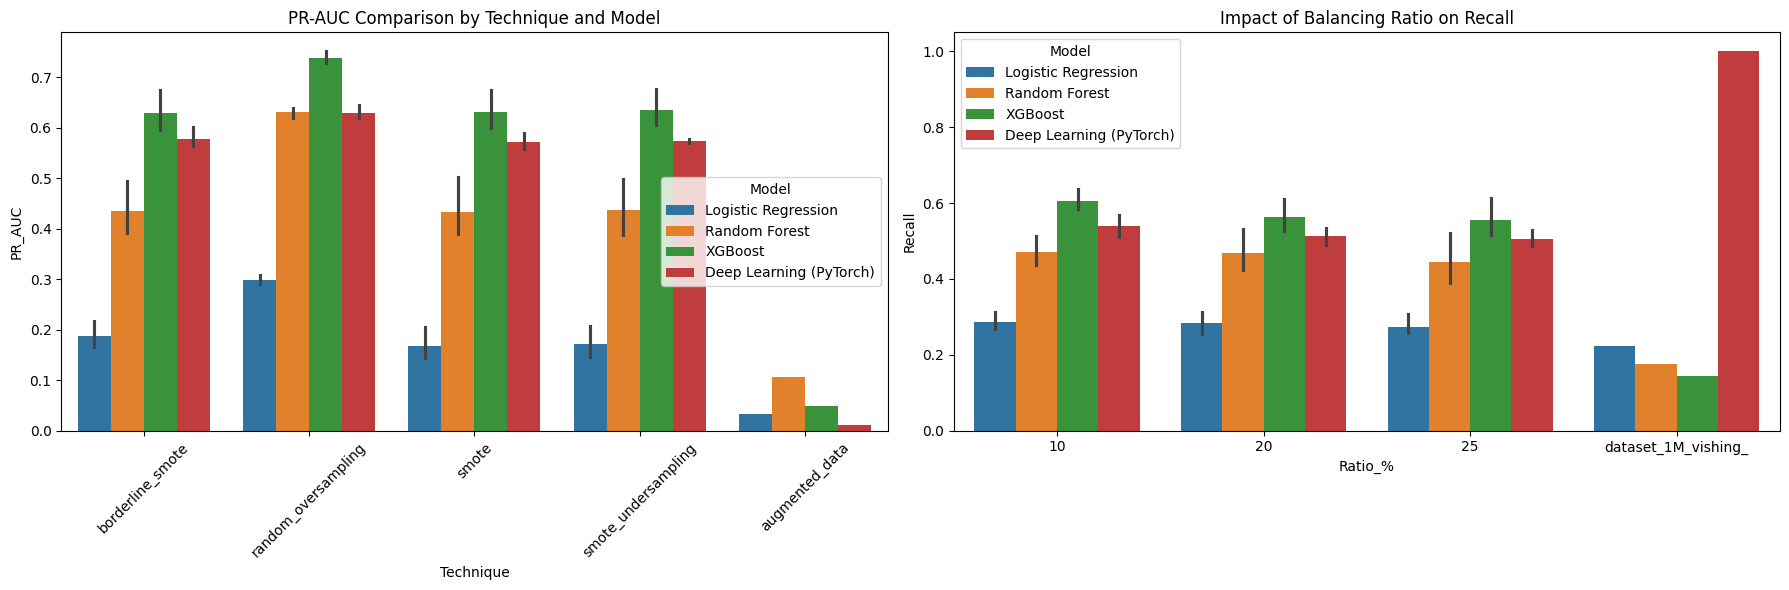

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=df_results, x='Technique', y='PR_AUC', hue='Model', ax=ax1)
ax1.set_title('PR-AUC Comparison by Technique and Model')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

sns.barplot(data=df_results, x='Ratio_%', y='Recall', hue='Model', ax=ax2)
ax2.set_title('Impact of Balancing Ratio on Recall')

plt.tight_layout()
plt.show()


## 5. Best Model Analysis (Confusion Matrix)

We select the combination of Technique, Ratio, and Model that obtained the best PR-AUC and plot its confusion matrix on the Hold-Out Set.


--- Best combination identified (by PR-AUC) ---
Model            : XGBoost
Technique        : random_oversampling
Ratio            : 10%
PR_AUC           : 0.7511
Optimal threshold: 0.5921
S3 location      : s3://poc-fraude-vishing/proyecto/modelos/random_oversampling/10/XGBoost.pkl

Wrapper loaded  : VishingModelWrapper(model='XGBoost', technique='random_oversampling', ratio='10', n_features=44, threshold=0.5921)
Features        : 44 columns
Internal threshold: 0.5921
Scaler included : No (tree, not required)


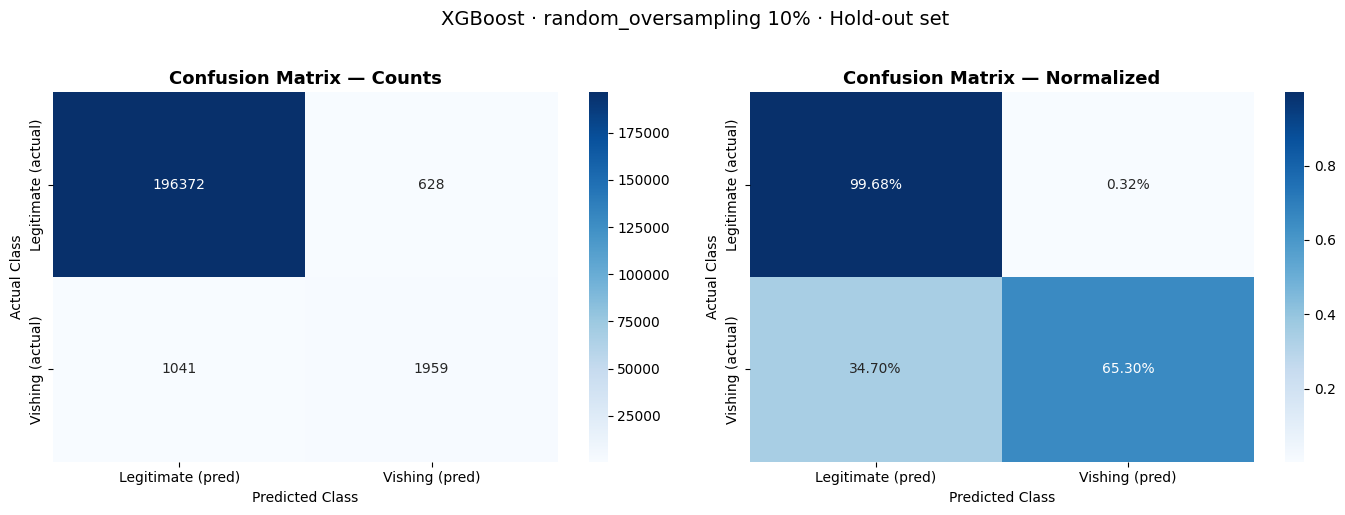


  True Negatives  (TN) : 196372  — Legitimate correctly identified
  False Positives (FP) :    628  — Legitimate flagged as Vishing
  False Negatives (FN) :   1041  — Vishing not detected  ← critical risk
  True Positives  (TP) :   1959  — Vishing correctly detected
  Recall    (Sensitivity)   : 0.6530
  Precision                 : 0.7572
  F1-Score                  : 0.7013
  ROC-AUC                   : 0.9784
  PR-AUC                    : 0.7511


In [14]:
best_row           = df_results_sorted.iloc[0]
best_technique     = best_row['Technique']
best_ratio         = best_row['Ratio_%']
best_model_name    = best_row['Model']
s3_best_model_path = best_row['S3_Model_Path']

print(f"--- Best combination identified (by PR-AUC) ---")
print(f"Model            : {best_model_name}")
print(f"Technique        : {best_technique}")
print(f"Ratio            : {best_ratio}%")
print(f"PR_AUC           : {best_row['PR_AUC']:.4f}")
print(f"Optimal threshold: {best_row['Threshold']:.4f}")
print(f"S3 location      : {s3_best_model_path}")

# ── Load the VishingModelWrapper from S3 ─────────────────────────────────────
from io import BytesIO
parsed_url   = urlparse(s3_best_model_path)
s3_model_key = parsed_url.path.lstrip('/')

with BytesIO() as f:
    s3_client.download_fileobj(Bucket=bucket, Key=s3_model_key, Fileobj=f)
    f.seek(0)
    best_wrapper = joblib.load(f)

print(f"\nWrapper loaded  : {best_wrapper}")
print(f"Features        : {len(best_wrapper.feature_names)} columns")
print(f"Internal threshold: {best_wrapper.threshold:.4f}")
print(f"Scaler included : {'Yes' if best_wrapper.scaler is not None else 'No (tree, not required)'}")

# ── Evaluation on the hold-out using the wrapper ─────────────────────────────
X_test_ordered = X_test[best_wrapper.feature_names]
if best_wrapper.scaler is not None:
    X_te_best = best_wrapper.scaler.transform(X_test_ordered)
else:
    X_te_best = X_test_ordered.values

y_prob_best = best_wrapper.model.predict_proba(X_te_best)[:, 1]
y_pred_best = (y_prob_best >= best_wrapper.threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['Legitimate (pred)', 'Vishing (pred)'],
    yticklabels=['Legitimate (actual)', 'Vishing (actual)']
)
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual Class')
axes[0].set_xlabel('Predicted Class')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
    xticklabels=['Legitimate (pred)', 'Vishing (pred)'],
    yticklabels=['Legitimate (actual)', 'Vishing (actual)']
)
axes[1].set_title('Confusion Matrix — Normalized', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual Class')
axes[1].set_xlabel('Predicted Class')

plt.suptitle(f'{best_model_name} · {best_technique} {best_ratio}% · Hold-out set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"  True Negatives  (TN) : {tn:>6}  — Legitimate correctly identified")
print(f"  False Positives (FP) : {fp:>6}  — Legitimate flagged as Vishing")
print(f"  False Negatives (FN) : {fn:>6}  — Vishing not detected  ← critical risk")
print(f"  True Positives  (TP) : {tp:>6}  — Vishing correctly detected")
print(f"{'='*50}")
print(f"  Recall    (Sensitivity)   : {tp/(tp+fn):.4f}")
print(f"  Precision                 : {tp/(tp+fp):.4f}")
print(f"  F1-Score                  : {2*tp/(2*tp+fp+fn):.4f}")
print(f"  ROC-AUC                   : {roc_auc_score(y_test, y_prob_best):.4f}")
print(f"  PR-AUC                    : {average_precision_score(y_test, y_prob_best):.4f}")
print(f"{'='*50}")


## 6. Feature Importance — XGBoost

XGBoost offers native interpretability via variable importance by accumulated Gain.


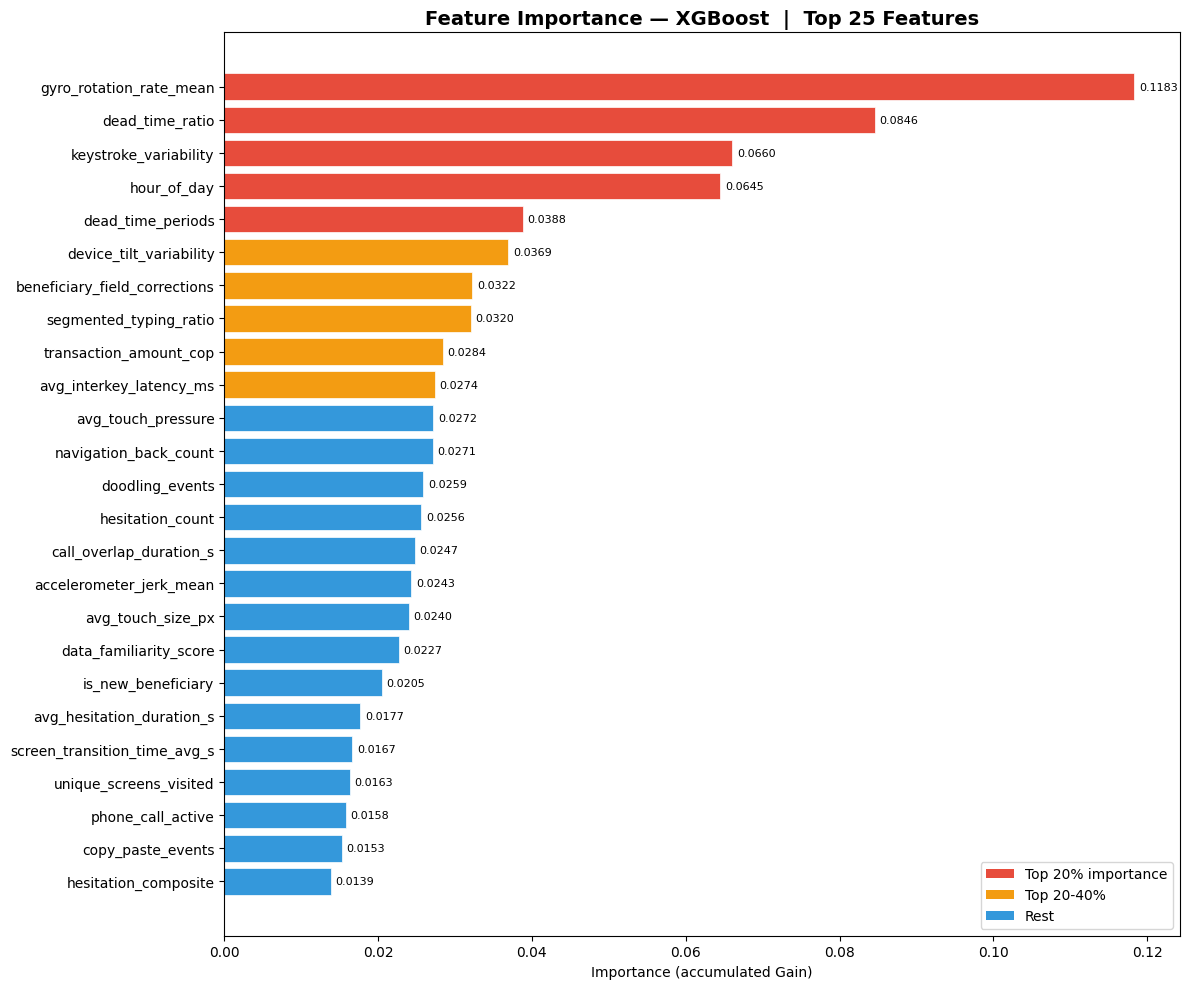

Top 15 features (XGBoost — Gain):
Feature                                    Importance
-------------------------------------------------------
gyro_rotation_rate_mean                        0.1183
dead_time_ratio                                0.0846
keystroke_variability                          0.0660
hour_of_day                                    0.0645
dead_time_periods                              0.0388
device_tilt_variability                        0.0369
beneficiary_field_corrections                  0.0322
segmented_typing_ratio                         0.0320
transaction_amount_cop                         0.0284
avg_interkey_latency_ms                        0.0274
avg_touch_pressure                             0.0272
navigation_back_count                          0.0271
doodling_events                                0.0259
hesitation_count                               0.0256
call_overlap_duration_s                        0.0247


In [19]:
if 'XGBoost' in models:
    xgb_model = copy.deepcopy(models['XGBoost'])
    # Rebuild the dataset selected as best so this cell is self-contained.
   
    best_data_path = 's3://poc-fraude-vishing/proyecto/data/balanced/augmented/random_oversampling/10.parquet'
    df_best = pd.read_parquet(best_data_path)
    df_best = df_best.drop(columns=[c for c in cols_to_drop if c in df_best.columns], errors='ignore')
    X_best = df_best.drop(columns=['is_vishing'])
    y_best = df_best['is_vishing']

    xgb_model.fit(X_best.values, y_best)

    FEATURE_NAMES = X_best.columns.tolist()

    fi = pd.DataFrame({
        'feature'   : FEATURE_NAMES,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(12, 10))
    top_fi = fi.head(25)

    q80 = top_fi['importance'].quantile(0.80)
    q60 = top_fi['importance'].quantile(0.60)
    colors_fi = ['#e74c3c' if v >= q80 else '#f39c12' if v >= q60 else '#3498db'
                 for v in top_fi['importance']]

    bars = ax.barh(range(len(top_fi)), top_fi['importance'].values,
                   color=colors_fi, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(top_fi)))
    ax.set_yticklabels(top_fi['feature'].values)
    ax.set_xlabel('Importance (accumulated Gain)')
    ax.set_title('Feature Importance — XGBoost  |  Top 25 Features', fontweight='bold', fontsize=14)
    ax.invert_yaxis()
    for i, v in enumerate(top_fi['importance'].values):
        ax.text(v + top_fi['importance'].max()*0.005, i, f'{v:.4f}', va='center', fontsize=8)

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor='#e74c3c', label='Top 20% importance'),
        Patch(facecolor='#f39c12', label='Top 20-40%'),
        Patch(facecolor='#3498db', label='Rest'),
    ], loc='lower right')

    plt.tight_layout()
    plt.show()
    
    print('Top 15 features (XGBoost — Gain):')
    print(f"{'Feature':40s} {'Importance':>12s}")
    print('-' * 55)
    for _, row in fi.head(15).iterrows():
        print(f"{row['feature']:40s} {row['importance']:12.4f}")
else:
    print("XGBoost is not in the models dictionary, importances are not plotted.")


## 7. Precision-Recall Curve and Decision Threshold Analysis


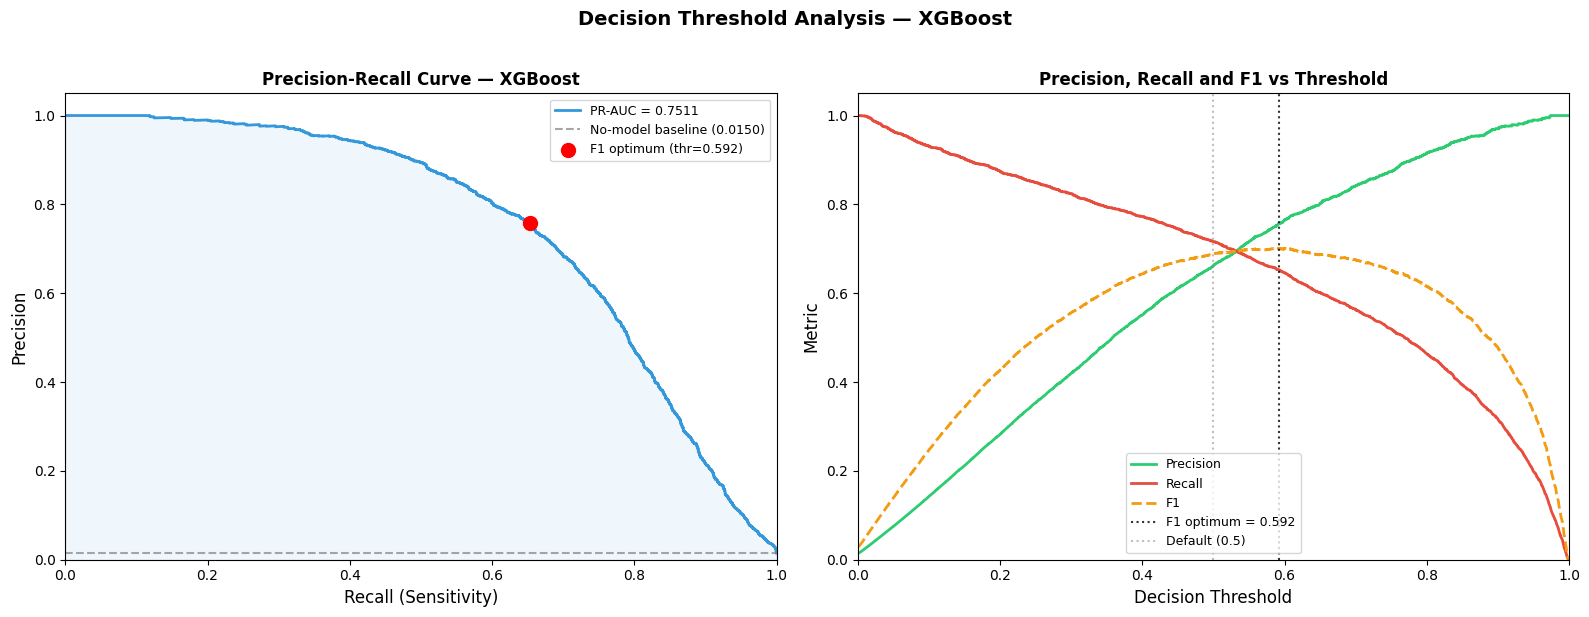

  With optimal threshold (max F1) = 0.5921
    Recall    : 0.6530
    Precision : 0.7572
    F1        : 0.7013
  With default threshold = 0.5
    Recall    : 0.6530
    Precision : 0.7572
    F1        : 0.7013


In [20]:
precisions_c, recalls_c, thresholds_c = precision_recall_curve(y_test, y_prob_best)
pr_auc_val = average_precision_score(y_test, y_prob_best)

f1_scores_c = (2 * precisions_c[:-1] * recalls_c[:-1]
               / (precisions_c[:-1] + recalls_c[:-1] + 1e-9))
best_idx  = np.argmax(f1_scores_c)
best_thr  = thresholds_c[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PR curve
axes[0].plot(recalls_c, precisions_c, color='#3498db', linewidth=2,
             label=f'PR-AUC = {pr_auc_val:.4f}')
axes[0].axhline(y=y_test.mean(), color='gray', linestyle='--', alpha=0.7,
                label=f'No-model baseline ({y_test.mean():.4f})')
axes[0].fill_between(recalls_c, precisions_c, alpha=0.08, color='#3498db')
axes[0].scatter([recalls_c[best_idx]], [precisions_c[best_idx]], s=100,
                color='red', zorder=5, label=f'F1 optimum (thr={best_thr:.3f})')
axes[0].set_xlabel('Recall (Sensitivity)', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title(f'Precision-Recall Curve — {best_model_name}', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.05)

# Metrics vs threshold
axes[1].plot(thresholds_c, precisions_c[:-1], label='Precision', color='#2ecc71', linewidth=2)
axes[1].plot(thresholds_c, recalls_c[:-1],    label='Recall',    color='#e74c3c', linewidth=2)
axes[1].plot(thresholds_c, f1_scores_c,       label='F1',        color='#f39c12', linewidth=2, linestyle='--')
axes[1].axvline(x=best_thr, color='black', linestyle=':', alpha=0.8,
                label=f'F1 optimum = {best_thr:.3f}')
axes[1].axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, label='Default (0.5)')
axes[1].set_xlabel('Decision Threshold', fontsize=12)
axes[1].set_ylabel('Metric', fontsize=12)
axes[1].set_title('Precision, Recall and F1 vs Threshold', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.05)

plt.suptitle(f'Decision Threshold Analysis — {best_model_name}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

y_pred_opt = (y_prob_best >= best_thr).astype(int)

print(f"{'='*62}")
print(f"  With optimal threshold (max F1) = {best_thr:.4f}")
print(f"    Recall    : {recall_score(y_test, y_pred_opt):.4f}")
print(f"    Precision : {precision_score(y_test, y_pred_opt):.4f}")
print(f"    F1        : {f1_score(y_test, y_pred_opt):.4f}")
print(f"{'='*62}")
print(f"  With default threshold = 0.5")
print(f"    Recall    : {recall_score(y_test, y_pred_best):.4f}")
print(f"    Precision : {precision_score(y_test, y_pred_best):.4f}")
print(f"    F1        : {f1_score(y_test, y_pred_best):.4f}")
print(f"{'='*62}")


## 8. Inference from JSON — production usage

Each serialized wrapper exposes three methods that accept a JSON with named features:

| Method | Output |
|---|---|
| `predict(json)` | `0` (legitimate) or `1` (vishing) |
| `predict_proba_raw(json)` | `{"legitimate": float, "vishing": float}` |
| `predict_full(json)` | full dict: label + probabilities + threshold used |

All accept a `dict`, a JSON `str`, or a `list[dict]` for batch.

In [ ]:
import json

# ── Load any wrapper from S3 ─────────────────────────────────────────────────
# (best_wrapper is already in memory from the previous cell; this block shows
#  how to load it in an external service from its S3 path)
#
# s3_path = "s3://poc-fraude-vishing/proyecto/modelos/smote/20/XGBoost.pkl"
# parsed  = urlparse(s3_path)
# with BytesIO() as f:
#     s3_client.download_fileobj(Bucket="poc-fraude-vishing",
#                                Key=parsed.path.lstrip('/'), Fileobj=f)
#     f.seek(0)
#     wrapper = joblib.load(f)

wrapper = best_wrapper   # reuse the one loaded in the previous cell

# ── 1. Single case — JSON string (simulating a REST input) ────────────────────
sample_idx    = X_test[y_test == 1].index[0]       # take a real vishing case
sample_record = X_test.loc[sample_idx].to_dict()
sample_json   = json.dumps(sample_record)

print("=== predict_full() — single observation (JSON string) ===")
result = wrapper.predict_full(sample_json)
print(json.dumps(result, indent=2))

# ── 2. Single case — dict ─────────────────────────────────────────────────────
print("\n=== predict() and predict_proba_raw() — dict ===")
print("  predict         :", wrapper.predict(sample_record))         # 0 or 1
print("  predict_proba_raw:", wrapper.predict_proba_raw(sample_record))  # probs

# ── 3. Batch — list of dicts ──────────────────────────────────────────────────
print("\n=== predict_full() — batch (5 observations) ===")
batch         = X_test.head(5).to_dict(orient='records')
batch_results = wrapper.predict_full(batch)
for i, r in enumerate(batch_results):
    print(f"  Obs {i}: {r['label']:12s}  "
          f"P_vishing={r['probability_vishing']:.6f}  "
          f"thr={r['threshold_used']}")

# ── 4. Validation: missing feature ───────────────────────────────────────────
print("\n=== Validation: input with a missing feature ===")
bad_input = {k: v for k, v in sample_record.items()
             if k != wrapper.feature_names[0]}
try:
    wrapper.predict_full(bad_input)
except ValueError as e:
    print(f"  Error correctly caught → {e}")

# ── 5. Listing of expected features ──────────────────────────────────────────
print(f"\n=== Features expected by this wrapper ({len(wrapper.feature_names)} total) ===")
for i, feat in enumerate(wrapper.feature_names):
    print(f"  [{i:2d}] {feat}")
